# Tanh soft clipping for analog distortion

Hyperbolic tangent compresses large amplitudes while leaving small signals nearly unchanged — the same idea used in the FPGA **AnalogTanhDistortion** design.

In [4]:
!pip install matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 10.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.2/355.2 kB 7.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 11.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 10.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 10.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 7.7 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Presentation-friendly defaults
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "font.size": 14,
    "axes.labelsize": 15,
    "axes.titlesize": 16,
    "legend.fontsize": 12,
    "lines.linewidth": 2.5,
})

x = np.linspace(-2 * np.pi, 2 * np.pi, 2000)
amplitude = 2.0  # sine drive level (try 0.5, 2, 5 to see soft vs hard clipping)

## 1. The $\tanh$ transfer function

Saturates smoothly toward $\pm 1$ instead of hard clipping at a threshold.

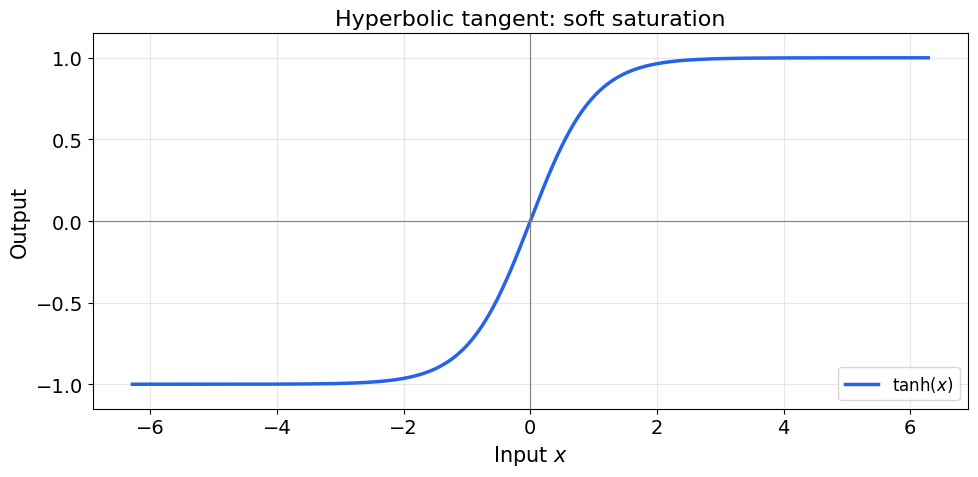

In [6]:
fig, ax = plt.subplots()
ax.plot(x, np.tanh(x), color="#2563eb", label=r"$\tanh(x)$")
ax.axhline(0, color="gray", linewidth=0.8)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_xlabel("Input $x$")
ax.set_ylabel("Output")
ax.set_title(r"Hyperbolic tangent: soft saturation")
ax.set_ylim(-1.15, 1.15)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 2. A sine wave (input signal)

Typical audio-like stimulus before distortion.

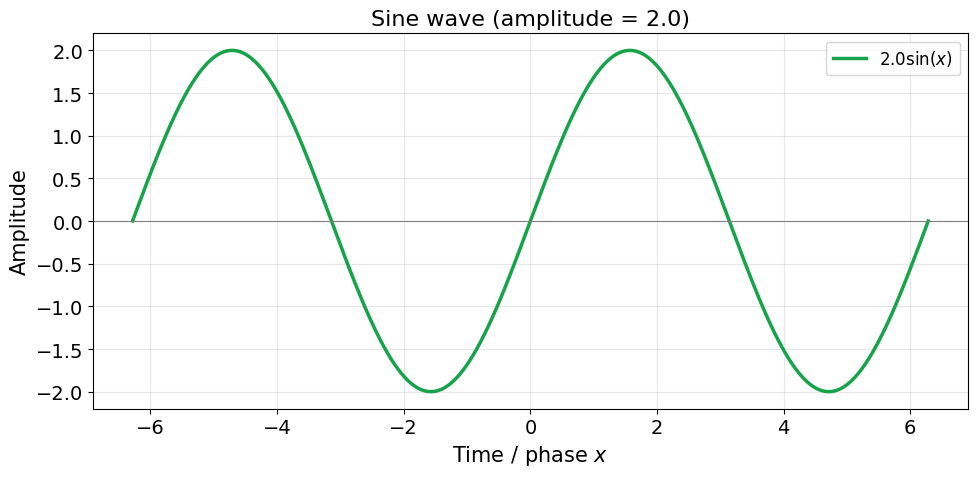

In [7]:
sine = amplitude * np.sin(x)

fig, ax = plt.subplots()
ax.plot(x, sine, color="#16a34a", label=rf"${amplitude}\sin(x)$")
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_xlabel("Time / phase $x$")
ax.set_ylabel("Amplitude")
ax.set_title(rf"Sine wave (amplitude = {amplitude})")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 3. Sine through $\tanh$ (distorted output)

Each sample is passed through the nonlinearity: $y(x) = \tanh\big(A\sin(x)\big)$. Peaks are rounded and harmonics appear — **soft clipping**.

## 4. Multiple amplitudes through $\tanh$

Higher drive level pushes more of the waveform into the saturated region of $\tanh$ — stronger soft clipping and more harmonic content.

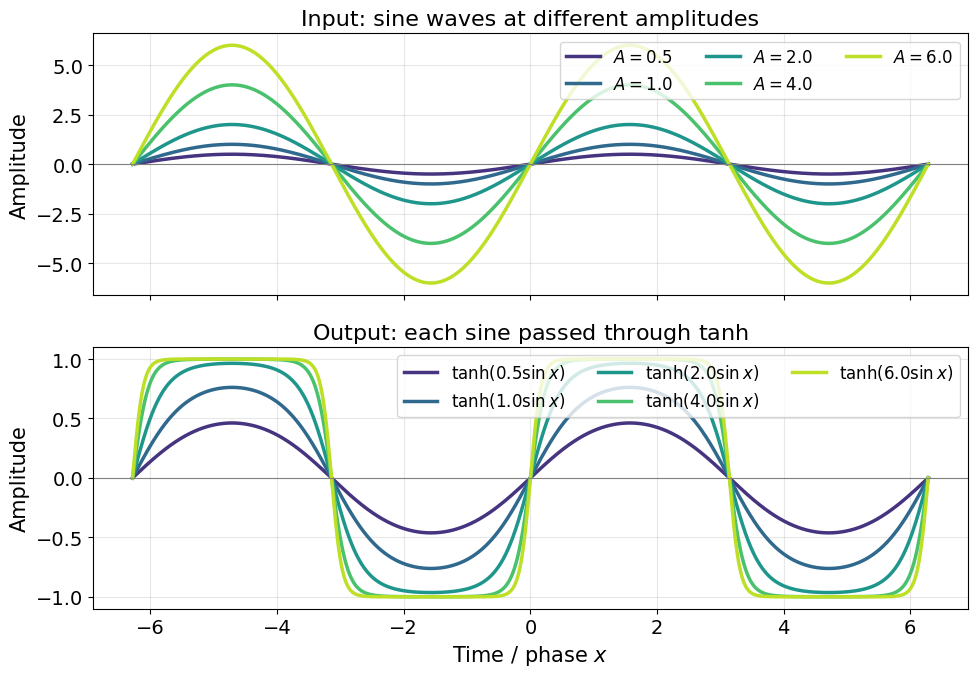

In [10]:
amplitudes = [0.5, 1.0, 2.0, 4.0, 6.0]
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(amplitudes)))

fig, (ax_in, ax_out) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

for A, c in zip(amplitudes, colors):
    sine_a = A * np.sin(x)
    distorted_a = np.tanh(sine_a)
    ax_in.plot(x, sine_a, color=c, label=rf"$A={A}$")
    ax_out.plot(x, distorted_a, color=c, label=rf"$\tanh({A}\sin x)$")

ax_in.axhline(0, color="gray", linewidth=0.8)
ax_in.set_ylabel("Amplitude")
ax_in.set_title("Input: sine waves at different amplitudes")
ax_in.legend(loc="upper right", ncol=3)
ax_in.grid(True, alpha=0.3)

ax_out.axhline(0, color="gray", linewidth=0.8)
ax_out.set_xlabel("Time / phase $x$")
ax_out.set_ylabel("Amplitude")
ax_out.set_title(r"Output: each sine passed through $\tanh$")
ax_out.set_ylim(-1.1, 1.1)
ax_out.legend(loc="upper right", ncol=3)
ax_out.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

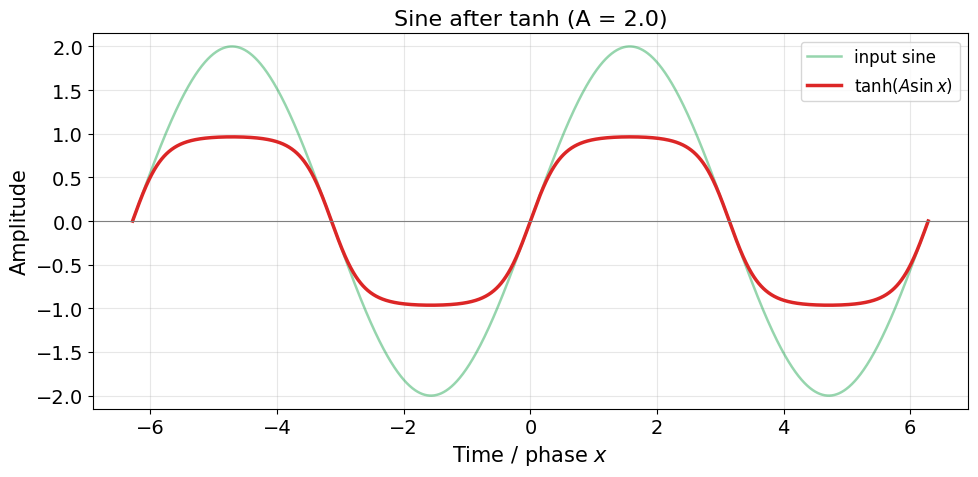

In [9]:
distorted = np.tanh(sine)

fig, ax = plt.subplots()
ax.plot(x, sine, color="#16a34a", alpha=0.45, linewidth=1.8, label="input sine")
ax.plot(x, distorted, color="#dc2626", label=r"$\tanh(A\sin x)$")
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_xlabel("Time / phase $x$")
ax.set_ylabel("Amplitude")
ax.set_title(rf"Sine after tanh (A = {amplitude})")
ax.set_ylim(-2.15, 2.15)
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Summary (one slide)

Input, transfer curve, and output on the same axes.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

axes[0].plot(x, np.tanh(x), color="#2563eb")
axes[0].set_title(r"$\tanh(x)$")
axes[0].set_xlabel("$x$")
axes[0].set_ylim(-1.1, 1.1)
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, sine, color="#16a34a")
axes[1].set_title(rf"$A\sin x$  (A={amplitude})")
axes[1].set_xlabel("$x$")
axes[1].grid(True, alpha=0.3)

axes[2].plot(x, sine, color="#16a34a", alpha=0.35, label="input")
axes[2].plot(x, distorted, color="#dc2626", label="tanh(sine)")
axes[2].set_title(r"$\tanh(A\sin x)$")
axes[2].set_xlabel("$x$")
axes[2].set_ylim(-1.1, 1.1)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

for ax in axes:
    ax.set_ylabel("Amplitude")

plt.tight_layout()
plt.show()